In [53]:
!pip install geopandas pandas matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [54]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [55]:
constituencies = gpd.read_file("wb_acs_map.json")
df = pd.read_csv("../csv_extraction/election_results_compiled.csv")

In [56]:
df["Modified_constituency_name"] = (
    df["Constituency"].str.upper().str.strip()
    + np.where(
        df["Category"] == "GEN",
        "",
        " (" + df["Category"].fillna("").str.strip() + ")"
    )
)

In [57]:
merged = constituencies.merge(df, left_on="ac_name", right_on="Modified_constituency_name")

## Constituency map

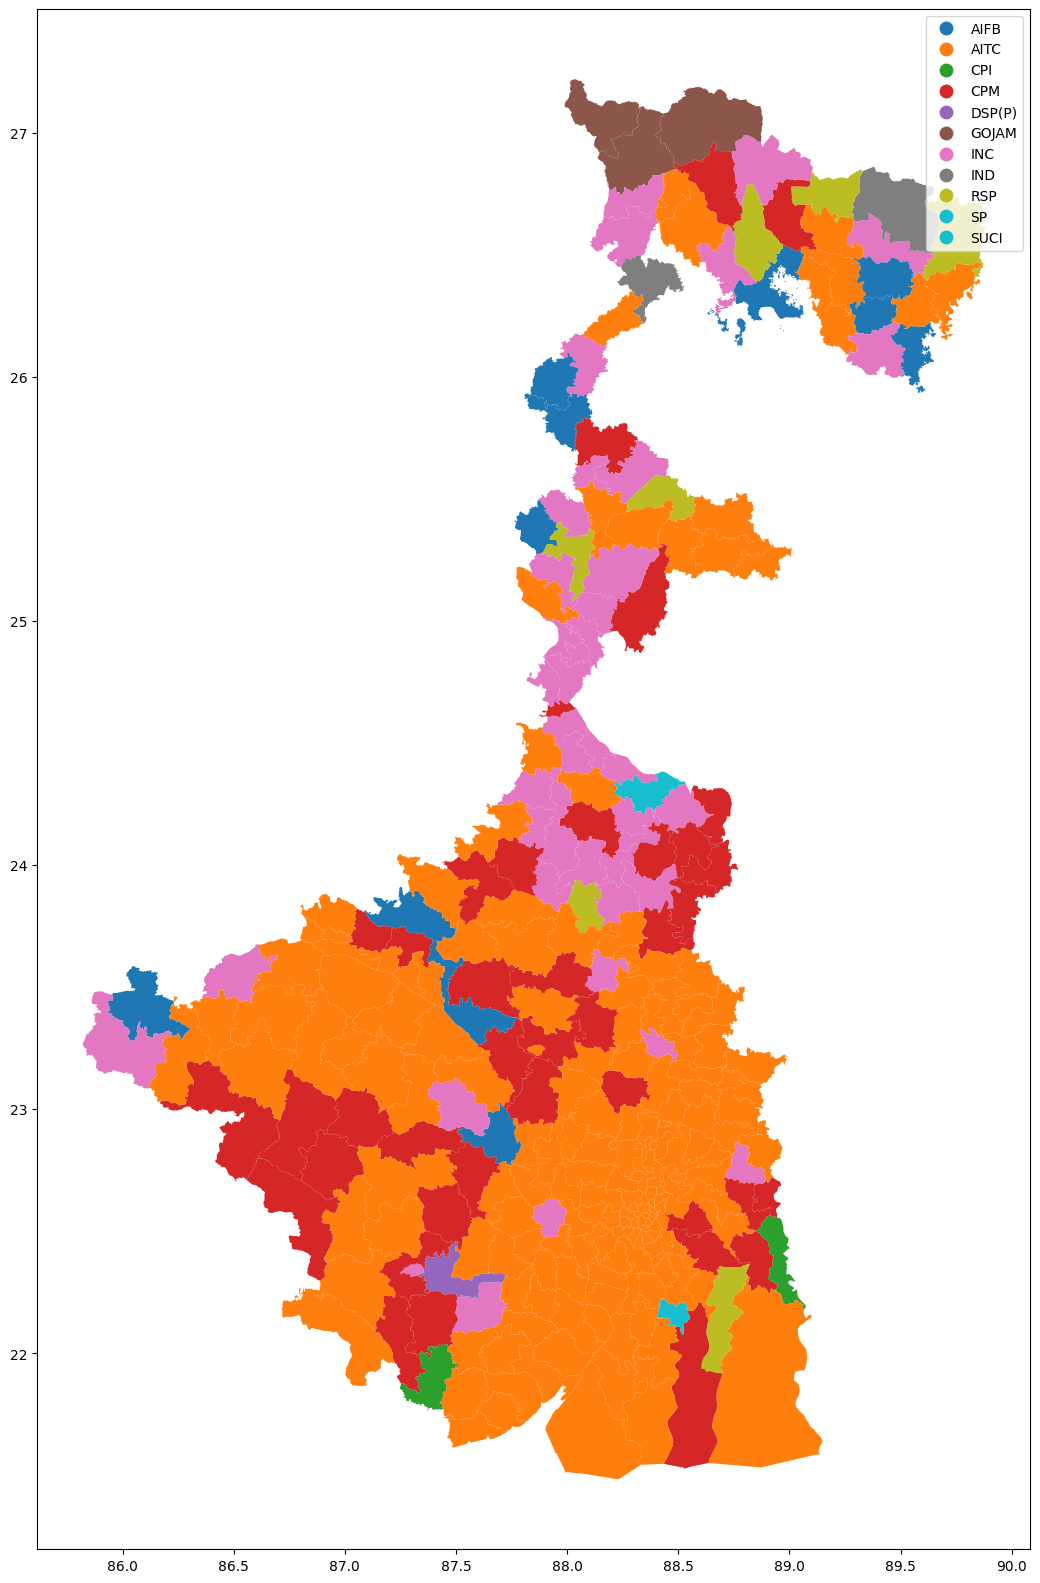

In [58]:
merged.plot(column="2011_winner", legend=True, figsize=(20, 20))
plt.show()

## Sankey chart

In [59]:
from collections import Counter
import plotly.graph_objects as go

In [60]:
# district = "Howrah"
# district_df = df[df["District"] == district].copy()
# print(district_df)

In [61]:
# years = [2011, 2016, 2021, 2026]

# for year in years:
#     district_df[f"{year}_pair"] = district_df[f"{year}_winner"] + "\nvs\n" + district_df[f"{year}_runnerup"]
#     district_df[f"{year}_node"] = str(year) + "\n" + district_df[f"{year}_pair"]


In [62]:
# flows = []
# for _, row in district_df.iterrows():
#     for i in range(len(years)-1):
#         flows.append((row[f"{years[i]}_node"], row[f"{years[i+1]}_node"]))

In [63]:

# flow_counts = Counter(flows)

In [64]:
# nodes = sorted(set(n for edge in flow_counts for n in edge))
# node_index = {node:i for i, node in enumerate(nodes)}

In [65]:
# source = []
# target = []
# value = []

# for (u, v), count in flow_counts.items():
#     source.append(node_index[u])
#     target.append(node_index[v])
#     value.append(count)

In [66]:
# fig = go.Figure(
#     go.Sankey(
#         arrangement="snap",
#         node = dict(label = nodes, pad = 20, thickness = 25, line = dict(color="black", width=0.5)),
#         link = dict(source = source, target = target, value = value)
#     )
# )

# fig.update_layout(
#     title = f"{district}: Winner-Runner up Evolution",
#     font_size = 12,
#     width = 1200,
#     height = 700
# )

# fig.show()

## All districts

In [67]:
districts_list = set(df["District"])
years = [2011, 2016, 2021, 2026]
print(districts_list)

{'Howrah', 'Purbo Medinipur', 'Darjeeling', 'Alipurduar', 'Hooghly', 'Uttar Dinajpur', 'Kolkata North', 'Dakshin Dinajpur', 'North 24 Parganas', 'Jalpaiguri', 'Kolkata South', 'Paschim Medinipur', 'Purulia', 'Birbhum', 'Bardhaman', 'South 24 Parganas', 'Malda', 'Coochbehar', 'Murshidabad', 'Bankura', 'Nadia'}


In [68]:
party_colors = {
    "AITC": "#34A853",
    "BJP": "#F57C00",
    "INC": "#1976D2",
    "CPI(M)": "#FF0000",
    "CPM": "#FF0000",
    "CPI": "#E53935",
    "AIFB": "#8B0000",
    "RSP": "#7B1FA2",
    "SUCI": "#C2185B",
    "IND": "#757575",
    "NOTA": "#BDBDBD"
}
default_colour = "#D3D3D3"


In [69]:
for d in districts_list:
    district_df = df[df["District"] == d].copy()


    for y in years:
        # district_df[f"{y}_pair"] = district_df[f"{y}_winner"] + "\nvs\n" + district_df[f"{y}_runnerup"]
        # district_df[f"{y}_node"] = str(y) + "\n" + district_df[f"{y}_pair"]
        district_df[f"{y}_id"] = (str(y) + "|" + district_df[f"{y}_winner"] + "|" + district_df[f"{y}_runnerup"])


    flows = []
    for _, row in district_df.iterrows():
        for i in range(len(years)-1):
            flows.append((row[f"{years[i]}_id"], row[f"{years[i+1]}_id"]))

    flow_counts = Counter(flows)


    nodes = sorted(set(n for edge in flow_counts for n in edge))
    node_index = {node:i for i, node in enumerate(nodes)}
    node_labels = []
    node_colours = []
    hover_text = []

    for n in nodes:
        year, winner, runner = n.split("|")
        node_labels.append(f"{winner}<br><b>vs</b><br>{runner}")
        node_colours.append(party_colors.get(winner, default_colour))
        hover_text.append(
            f"<b>{year}</b><br>"
            f"Winner: {winner}<br>"
            f"Runner-up: {runner}"
        )

    s = []
    t = []
    val = []
    link_colours = []

    for (u, v), count in flow_counts.items():
        s.append(node_index[u])
        t.append(node_index[v])
        val.append(count)
        year, winner, runner = u.split("|")
        colour  = party_colors.get(winner, default_colour).lstrip("#")

        r = int(colour[0:2], 16)
        g = int(colour[2:4], 16)
        b = int(colour[4:6], 16)

        link_colours.append(f"rgba({r}, {g}, {b}, 0.35)")

    fig = go.Figure(
        go.Sankey(
            arrangement="snap",
            node = dict(label = node_labels, pad = 22, thickness = 28, line = dict(color="black", width=0.7), color = node_colours, customdata = hover_text, hovertemplate = "%{customdata}<extra></extra>"),
            link = dict(source = s, target = t, value = val, color = link_colours, hovertemplate = "Flow: %{value} constituency(s)<extra></extra>")
        )
    )

    fig.update_layout(
        title = f"{d}: Winner-Runner up Evolution",
        font_size = 12,
        width = 1300,
        height = 1000,
        font = dict(size = 13),
        annotations = [
            dict(
                x = -0.01,
                y = 1.05,
                text = "<b>2011</b>",
                showarrow = False,
                font = dict(size = 18)
            ),
            dict(
                x = 0.32,
                y = 1.05,
                text = "<b>2016</b>",
                showarrow = False,
                font = dict(size = 18)
            ),
            dict(
                x = 0.68,
                y = 1.05,
                text = "<b>2021</b>",
                showarrow = False,
                font = dict(size = 18)
            ),
            dict(
                x = 1,
                y = 1.05,
                text = "<b>2026</b>",
                showarrow = False,
                font = dict(size = 18)
            ),
        ]
    )

    fig.write_html(f"sankey_{d.replace(' ', '_')}.html")

    fig.show()